In [78]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

AttributeError: This method only works with the ScalarFormatter

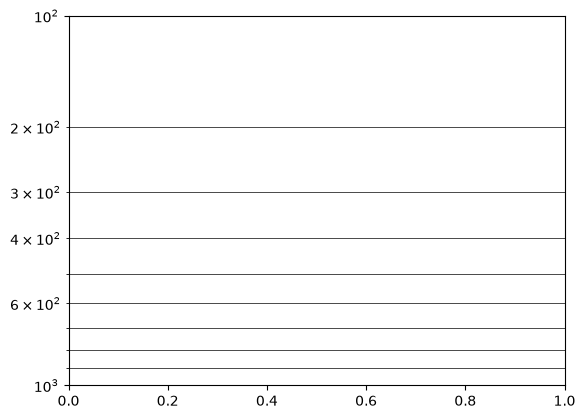

In [ ]:
from matplotlib import ticker

# Define constants
g = 9.81  
Cpd = 1004  
Lv = 2.5e6  
Rd = 287  
Rv = 461  
eps = Rd/Rv

# Define the skew function (provided in the lab instructions)
def skewT(temp, pres, skew=-20):
#Skews the temperature axis for a SkewT plot.
#temp: temperature values (deg C)
#pres: pressure values (hPa)
#skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)

# Define temperature and pressure arrays
temperatures = np.arange(-100,51,10) # Temperature in C
pressures = np.arange(100, 1001, 10) # Pressure in hPa

# Define the SkewT plot figures and axes
fig, ax = plt.subplots()

ax.set_ylim(1000, 100) 
ax.set_yscale('log')
for pressure in [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]:
    ax.axhline(pressure, color="black", linewidth=0.5)
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

ax.set_ylabel("Pressure (hPa)")

ax.set_xlim(-50, 50)  
ax.set_xlabel("Temperature (°C)")         


##---- PLOT TEMPERATURE LINES ----##

for T in temperatures:
    x = skewT(T, pressures)
    ax.plot(x, pressures, color="gray", linewidth=0.5)

##---- DRY ADIABAT ----##

for T in temperatures:
    #dry_adiabat = ((g / Cpd) * Rd * T) / (p * g)
    #dry_adiabat_C = dry_adiabat - 273.15

    dry_adiabat = (T + 273.15) * (pressures/1000)**(Rd/Cpd)
    dry_adiabat_C = dry_adiabat - 273.15
    y = skewT(dry_adiabat_C, pressures)
    ax.plot(y, pressures, color="orange", linewidth=0.5)

##---- MOIST ADIABAT ----##

for T in temperatures:
    saturation_vapor_pressure = 6.112 * np.exp(17.67 * (T - 273.15) / ((T - 29.65)))
    rs = eps * saturation_vapor_pressure / (pressures/100 - saturation_vapor_pressure)
    moist_adiabat_lr = (g/Cpd) * (1 + (Lv*rs) / (Rd*(Tk))) / (1 + (Lv**2 * rs)/(Cpd * Rv * (Tk)**2))
    moist_adiabat_line = (moist_adiabat_lr * Rd * (T + 273.15)) / (g * (p/100))
    moist_adiabat_line_C = moist_adiabat_line - 273.15  
    z = skewT(moist_adiabat_line_C, p)
    ax.plot(z, p, color="blue", linewidth=0.5)  


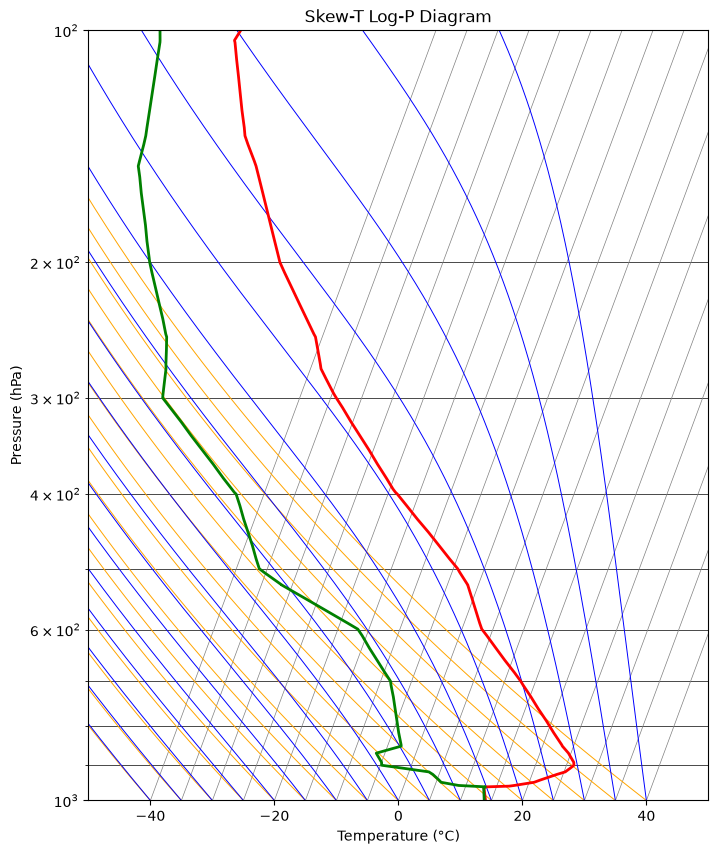

In [76]:
g = 9.81          # gravitational acceleration (m/s^2)
Cpd = 1004        # specific heat of dry air (J/(kg*K))
Lv = 2.5e6        # latent heat of vaporization (J/kg)
Rd = 287          # gas constant for dry air (J/(kg*K))
Rv = 461          # gas constant for water vapor (J/(kg*K))
eps = Rd / Rv     # approximately 0.622


def skewT(temp, pres, skew=-20):
    return temp + skew * np.log(pres / 1000.0)


def saturation_vapor_pressure(T):
    T_C = T - 273.15
    es = 6.112 * np.exp(
        17.67 * T_C / (T_C + 243.5))
    return es

def moist_dTdp(T, p):
    es = saturation_vapor_pressure(T)   # hPa
    p_hPa = p / 100.0
    rs = eps * es / (p_hPa - es)

    dTdp = (
        (Rd * T) / (p * Cpd) * (1 + (Lv * rs) / (Rd * T)) / (1 + (Lv**2 * rs) / (Cpd * Rv * T**2)) )
    return dTdp

# Pressure used for plotting
p = np.arange(100, 1001, 10)      # hPa

fig, ax = plt.subplots(figsize=(8, 10))

ax.set_yscale('log')

ax.set_ylim(1000, 100)
ax.set_xlim(-50, 50)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (hPa)")

ax.set_title("Skew-T Log-P Diagram")

for pressure in [1000, 900, 800, 700, 600,
                 500, 400, 300, 200, 100]:

    ax.axhline(pressure, color="black", linewidth=0.5)

temperatures = np.arange(-40, 41, 5)

for T in temperatures:
    x = skewT(T, p)
    ax.plot(x, p, color="gray", linewidth=0.5)

for T in temperatures:
    T0 = T + 273.15
    dry_adiabat = (T0 * (p / 1000.0) ** (Rd / Cpd))

    # Convert K -> °C
    dry_adiabat_C = dry_adiabat - 273.15

    # Apply skew
    x = skewT(dry_adiabat_C, p)

    ax.plot(x, p, color="orange", linewidth=0.7)

p_up = np.arange(
    1000,
    99,
    -1
)


for T0_C in temperatures:
    T_current = T0_C + 273.15
    T_values = [T_current]

    for i in range(len(p_up) - 1):
        p_current = p_up[i] * 100.0
        p_next = p_up[i + 1] * 100.0
        dp = p_next - p_current
        dTdp = moist_dTdp(T_current, p_current)
        T_current = (T_current + dTdp * dp)
        T_values.append(T_current)

    T_values = np.array(T_values)

    T_values_C = T_values - 273.15

    x = skewT(T_values_C, p_up)

    ax.plot(x, p_up, color="blue", linewidth=0.7)

sounding_file = "011026_SOUNDING.csv"
sounding_data = pd.read_csv(sounding_file)
sounding_temps = sounding_data["temperature_C"].values
sounding_dew = sounding_data["dew point temperature_C"].values
sounding_pres = sounding_data["pressure_hPa"].values

ax.plot(skewT(sounding_temps, sounding_pres), sounding_pres, color="red", linewidth=2.0)
ax.plot(skewT(sounding_dew, sounding_pres), sounding_pres, color="green", linewidth=2.0)

plt.show()

INTERPRETATION PROMPTS:

1) WHY DOES THE MOIST ADIABATIC LAPSE RATE Γm = −dT /dz GENERALLY INCREASE AS A SATURATED PARCEL ASCENDS AND COOLS?



The moist adiabtic lapse rate increases as a saturated parcel ascends and cools because when a parcel of air is saturated, the parcels capacity to hold water vapor is reached (i.e. the saturation vapor pressure is equal to the pressure exerted by the water vapor in the parcel) and any further cooling of the parcel will result in the water vapor condensing and turning into liquid water. As the water vapor undegoes the phase change to turn from vapor to liquid, latent heat is released as the vapor is cooled. The added heat into the surrounding environment results in the moist adiabatic lapse rate increasing as a saturated parcel cools, because the air parcels is loosing more heat (and therefore the temperature of the parcel is decreasing) as it ascends. 

2. AT A FIXED PRESSURE, HOW AND WHY DOES Γm DIFFER BETWEEN WARMER AND COLDER MOIST ADIABATS?

Γm at a fixed pressure differs between the warmer and cooler adiabats because at cooler temperatures, the lapse rate is

3. 